In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

import scarf
from scarf.agent import AnalysisConfig, RuntimeConfig, Study, analyze_rna_async
from scarf.writers import SparseToZarr

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

In [2]:
# Keep the synthetic dataset and report in a temporary folder.
teaching_directory = TemporaryDirectory(prefix="scarf-agent-teaching-")
# Choose the local path for the synthetic count store.
source = Path(teaching_directory.name) / "counts.zarr"
# Seed the generator so this example is reproducible.
rng = np.random.default_rng(39)
# Generate low background counts for the synthetic cells and genes.
counts = rng.poisson(1, size=(120, 2102)).astype(np.uint32)
# Plant a different expression pattern in each synthetic group.
for group in range(3):
    # Generate counts for this group's planted expression pattern.
    planted_counts = rng.poisson(4, size=(40, 40)).astype(np.uint32)
    # Add that pattern to the group's cells and marker genes.
    counts[group * 40 : (group + 1) * 40, 2 + group * 40 : 42 + group * 40] += planted_counts
# Check the synthetic matrix dimensions before writing it.
{"cells": counts.shape[0], "genes": counts.shape[1]}

{'cells': 120, 'genes': 2102}

In [3]:
# Add recognizable QC genes and names for the synthetic features.
names = ["MT-CO1", "RPL3", *[f"GENE{i}" for i in range(2100)]]
# Prepare a writer for the selected counts and metadata.
writer = SparseToZarr(
    csr_matrix(counts),
    str(source),
    [f"cell{i}" for i in range(120)],
    names,
    mem_budget="512M",
    nthreads=1,
)
# Write the prepared counts and metadata to the new store.
writer.dump()

In [4]:
# Open the synthetic count store without additional filtering.
prepared = scarf.DataStore(
    str(source),
    default_assay="RNA",
    min_features_per_cell=-1,
    nthreads=1,
    mem_budget="512M",
)
# Save the values in cell metadata using the stated selection.
prepared.cells.insert("sample", np.tile(["sample_A", "sample_B"], 60))
# Save the values in cell metadata using the stated selection.
prepared.cells.insert(
    "author_annotation", np.repeat(["planted_A", "planted_B", "planted_C"], 40)
)
# Record the input selection for the later preservation check.
initial_selection = prepared.cells.fetch_all("I").copy()
# Record the original metadata columns.
initial_columns = list(prepared.cells.columns)
# Release objects that are no longer needed.
del prepared, counts
# Check the original selection and metadata size.
{
    "selected cells": int(initial_selection.sum()),
    "metadata columns": len(initial_columns),
}

{'selected cells': 120, 'metadata columns': 9}

In [5]:
import json

from pydantic_ai.messages import ModelResponse, ToolCallPart
from pydantic_ai.models.function import FunctionModel

# Collect the decision stages seen by the scripted provider.
observed_decisions = []


# Return scripted decisions for the measured teaching example.
async def teaching_decision(messages, info):
    # Read the evidence payload supplied to the model.
    payload = json.loads(messages[-1].parts[-1].content)
    # Keep the measured evidence for the current decision.
    evidence = payload["evidence"]
    # Identify which structured decision the workflow requests.
    schema = info.output_tools[0].parameters_json_schema["title"]
    # Record the stage and schema requested by the workflow.
    observed_decisions.append({"stage": payload["stage"], "schema": schema})
    # Confirm the supplied study context without changing the cohort.
    if schema == "ContextDecision":
        # Explain why the supplied cohort and sample role are retained.
        answer = {"rationale": "Retain the supplied cohort and declared sample role."}
    # Leave synthetic clusters without biological identity claims.
    elif schema == "AnnotationDecision":
        # Return one provisional annotation for every measured cluster.
        answer = {
            "annotations": [
                {
                    "clusterId": row["clusterId"],
                    "identity": "unassigned",
                    "rationale": (
                        "Synthetic markers do not establish a biological cell identity."
                    ),
                }
                for row in evidence["clusters"]
            ]
        }
    # Request the registered higher-rank PCA experiment.
    elif evidence.get("decisionKind") == "pcProbe":
        # Find the option that measures 30 principal components.
        chosen = next(
            key
            for key, value in evidence["experiments"].items()
            if value["pcaDims"] == 30
        )
        # Link this experiment request to its baseline evidence.
        answer = {
            "action": "experiment",
            "optionIds": [chosen],
            "evidenceIds": ["c0"],
            "rationale": "Measure the registered higher-rank probe for this demonstration.",
        }
    # Choose a finalist only after the workflow has measured eligible options.
    elif "eligibleOptions" in evidence:
        # Use the first eligible finalist for this interface demonstration.
        chosen = evidence["eligibleOptions"][0]
        # Record the chosen option and the evidence supporting its eligibility.
        answer = {
            "action": "choose",
            "optionIds": [chosen],
            "evidenceIds": [chosen],
            "rationale": "Use the first measured eligible finalist for this demonstration.",
        }
    else:
        # Require the expected shortlist decision before selecting candidates.
        assert evidence["decisionKind"] == "nativeShortlist"
        # Shortlist the first two measured baseline partitions.
        chosen = [
            row["optionId"] for row in evidence["candidates"][0]["partitions"][:2]
        ]
        # Request marker review for both shortlisted partitions.
        answer = {
            "action": "shortlist",
            "optionIds": chosen,
            "evidenceIds": chosen,
            "rationale": (
                "Compare two measured baseline resolutions after the independent probes."
            ),
        }
    return ModelResponse(parts=[ToolCallPart("decision", answer)])

In [6]:
# Expose the scripted decision function through the model interface.
teaching_model = FunctionModel(teaching_decision)

In [7]:
# Run the bounded analysis with the synthetic study and scripted model.
result = await analyze_rna_async(
    source,
    run_dir=Path(teaching_directory.name) / "analysis",
    model=teaching_model,
    study=Study(
        context=(
            "Synthetic RNA with three planted expression patterns "
            "and two interleaved sample labels."
        ),
        objective=(
            "Demonstrate bounded population discovery without biological identity claims."
        ),
        sampleColumn="sample",
        excludedColumns=["author_annotation"],
    ),
    config=AnalysisConfig(assay="RNA", maxCandidates=4),
    runtime=RuntimeConfig(nthreads=1, memBudget="512M"),
)
# Require a completed analysis before inspecting final results.
assert result.status == "completed", result.status
# Inspect which parameter alternatives were measured.
pd.DataFrame(result.exploration_coverage["slots"])[
    ["candidateId", "axis", "status", "reason"]
]

,candidateId,axis,status,reason
0,c0,baseline,measured,None
1,c1,hvgCount,measured,None
2,c2,pcaDims,measured,None
3,c3,neighborsK,measured,None


In [8]:
# Compare requested and actual feature counts for every candidate.
pd.DataFrame(
    [
        {
            "candidate": row["candidateId"],
            "HVGs requested": row["parameters"]["hvgCount"],
            "HVGs selected": row["actualHvgCount"],
            "PCs": row["parameters"]["pcaDims"],
            "neighbors": row["parameters"]["neighborsK"],
        }
        for row in result.candidates
    ]
)

,candidate,HVGs requested,HVGs selected,PCs,neighbors
0,c0,1000,1000,21,11
1,c1,2000,2000,21,11
2,c2,1000,1000,30,11
3,c3,1000,1000,21,21


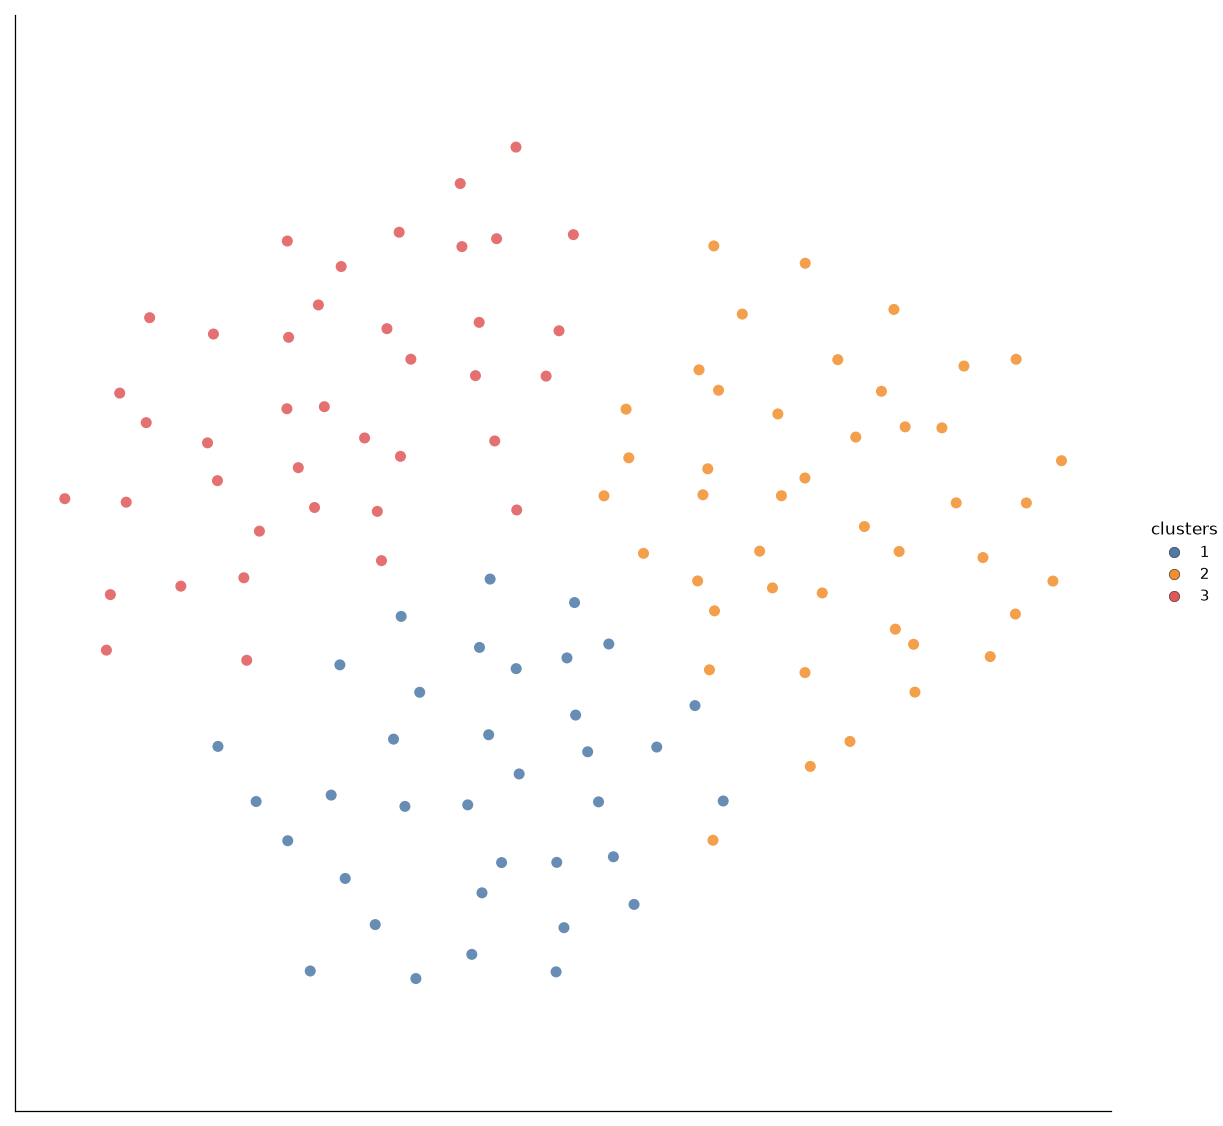

In [9]:
from IPython.display import display

# Create the final cluster figure from saved results.
embedding = result.plot_embedding(show=False)
# Display the final clustering on its saved UMAP.
display(embedding.figure)
# Close the displayed figure to release its resources.
embedding.close()

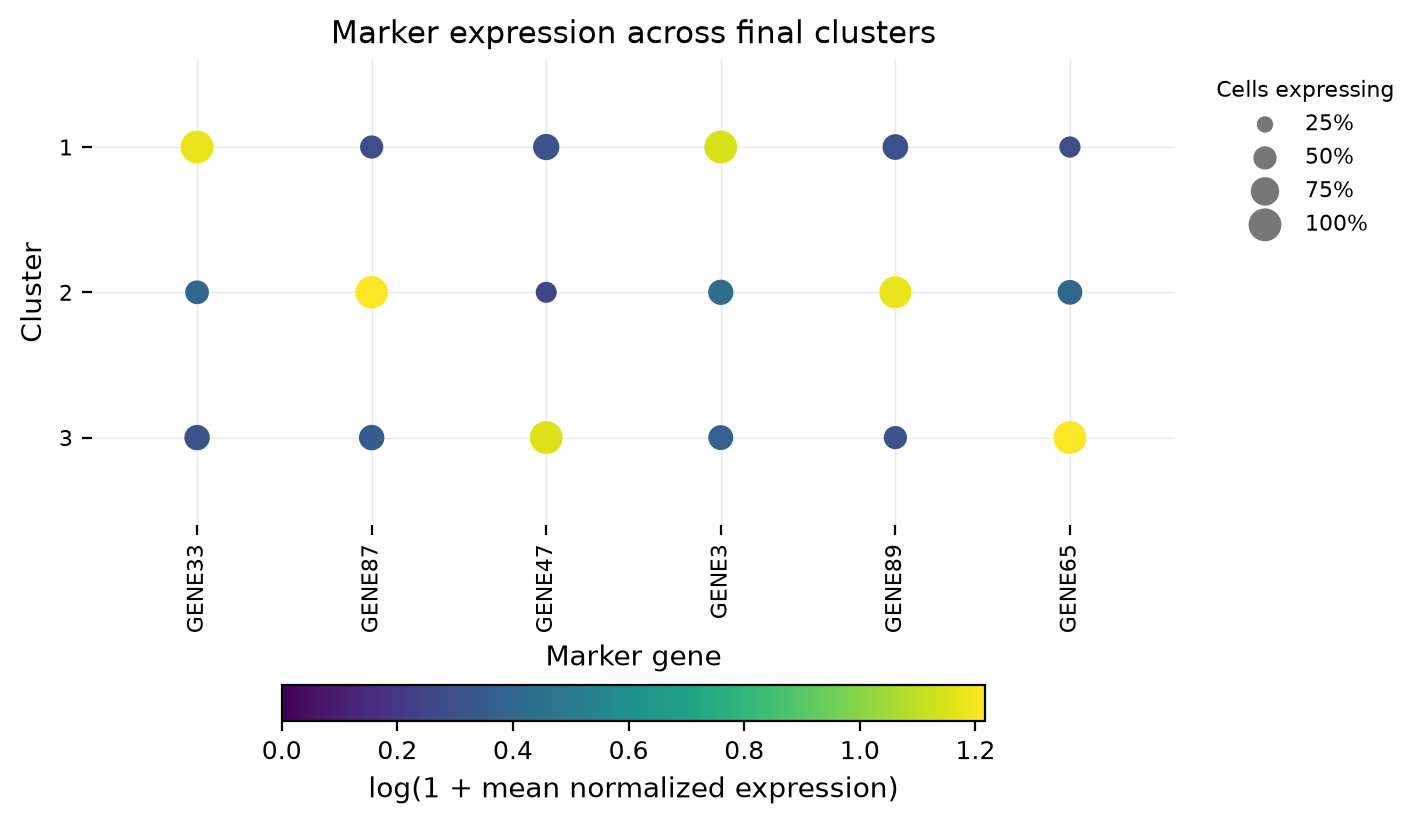

In [10]:
# Create the marker figure from the same final clustering.
marker_plot = result.plot_markers(show=False)
# Display the marker evidence for the final clusters.
display(marker_plot.figure)
# Close the displayed figure to release its resources.
marker_plot.close()

In [11]:
# Inspect the provisional identities and their supporting rationale.
annotation_table = pd.DataFrame(result.annotations)[
    ["clusterId", "identity", "confidence", "rationale"]
]
# Show each explanation in full rather than truncating it with an ellipsis.
with pd.option_context("display.max_colwidth", None):
    display(annotation_table)

,clusterId,identity,confidence,rationale
0,1,unassigned,low,Synthetic markers do not establish a biological cell identity.
1,2,unassigned,low,Synthetic markers do not establish a biological cell identity.
2,3,unassigned,low,Synthetic markers do not establish a biological cell identity.


In [12]:
# Read the compact summary linked to the final pipeline.
compact = result.compact_result
# Check that the compact summary points to the final pipeline.
assert compact["finalPipelineRunId"] == result.pipeline.run_id
# Read the settings selected by the scripted workflow.
selected = compact["selectedParameters"]
# Summarize the choices that determine the final analysis.
pd.Series(
    {
        "candidate": selected["candidateId"],
        "HVGs": selected["actualHvgCount"],
        "PCs": selected["pcaDims"],
        "neighbors": selected["neighborsK"],
        "resolution": selected["resolution"],
        "Harmony": selected["useHarmony"],
    },
    name="selected settings",
)

candidate        c0
HVGs           1000
PCs              21
neighbors        11
resolution      0.5
Harmony       False
Name: selected settings, dtype: object

In [13]:
from scarf.agent import open_analysis

# Reopen the saved analysis without requesting a new model decision.
reopened = open_analysis(result.run_dir)
# Regenerate the report from saved evidence.
report_path = reopened.report()
# Recheck recorded decisions against their saved evidence.
replayed = reopened.replay_decisions()
# Check that every recorded decision passes offline replay.
assert all(row["valid"] for row in replayed)
# Reopen the original input to verify its selection and metadata.
after = scarf.DataStore(str(source), zarr_mode="r", nthreads=1, mem_budget="512M")
# Check that the agent did not add or remove input metadata columns.
assert list(after.cells.columns) == initial_columns
# Verify that the original selected-cell mask is unchanged.
np.testing.assert_array_equal(after.cells.fetch_all("I"), initial_selection)
# Summarize the reopened analysis and its replay checks.
{
    "status": reopened.status,
    "pipeline invocations": len(reopened.pipeline_runs),
    "model decisions": len(observed_decisions),
    "offline replay checks": len(replayed),
    "report": report_path.name,
}

{'status': 'completed',
 'pipeline invocations': 7,
 'model decisions': 5,
 'offline replay checks': 5,
 'report': 'report.html'}